In [ ]:

import pandas as pd
import numpy as np
# lets import train test split for splitting the data
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Lasso 
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


##Para descativar la exclusion temporalmente y que pueda usar este enviroment: (para el proyecto)
PS C:\Users\danie> Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass
PS C:\Users\danie> .\proyecto_modulo_4_env\Scripts\Activate.ps1

#recuerda que para poder activar el enviroment, tienes que estsar en la ubicación donde se encuentra

In [194]:
datos=pd.read_csv("SeoulBikeData.csv",encoding="cp1252")
df_datos=pd.DataFrame(datos)
df_datos

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [195]:
df_datos.dtypes

Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object

In [196]:
df_datos['Date']=pd.to_datetime(df_datos['Date'],format="%d/%m/%Y").dt.date

In [197]:
df_datos['Month']=pd.to_datetime(df_datos['Date']).dt.month
df_datos['Week_day']=pd.to_datetime(df_datos['Date']).dt.day_of_week
df_datos['Day_Number']=pd.to_datetime(df_datos['Date']).dt.day
df_datos['Anio']=pd.to_datetime(df_datos['Date']).dt.year
df_datos['hora_sin']=np.sin(2*np.pi*df_datos['Hour']/24)
df_datos['hora_cos']=np.cos(2*np.pi*df_datos['Hour']/24)
df_datos['Month_sin']=np.sin(2*np.pi*df_datos['Hour']/12)
df_datos['Mont_cos']=np.cos(2*np.pi*df_datos['Hour']/12)
df_datos['es_Weeknd']=0
df_datos.loc[(df_datos['Week_day']>4),'es_Weeknd']=1
df_datos['es_nevado']=0
df_datos.loc[(df_datos['Snowfall (cm)']>0),'es_nevado']=1
df_datos['es_lluvioso']=0
df_datos.loc[(df_datos['Rainfall(mm)']>0),'es_lluvioso']=1
#Estandarizamos variables:
cols_a_estandarizar=["Temperature(°C)",
"Humidity(%)",
"Wind speed (m/s)",
"Visibility (10m)",
"Dew point temperature(°C)",
"Solar Radiation (MJ/m2)"]

scaler = StandardScaler()

df_datos[["Temperature(°C)_scaler",
"Humidity(%)_scaler",
"Wind speed (m/s)_scaler",
"Visibility (10m)_scaler",
"Dew point temperature(°C)_scaler",
"Solar Radiation (MJ/m2)_scaler"]]=scaler.fit_transform(df_datos[cols_a_estandarizar])







In [198]:
df_datos

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),...,Mont_cos,es_Weeknd,es_nevado,es_lluvioso,Temperature(°C)_scaler,Humidity(%)_scaler,Wind speed (m/s)_scaler,Visibility (10m)_scaler,Dew point temperature(°C)_scaler,Solar Radiation (MJ/m2)_scaler
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,1.000000e+00,0,0,0,-1.513957,-1.042483,0.458476,0.925871,-1.659605,-0.655132
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,8.660254e-01,0,0,0,-1.539074,-0.993370,-0.892561,0.925871,-1.659605,-0.655132
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,5.000000e-01,0,0,0,-1.580936,-0.944257,-0.699556,0.925871,-1.667262,-0.655132
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,6.123234e-17,0,0,0,-1.597680,-0.895144,-0.796059,0.925871,-1.659605,-0.655132
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,-5.000000e-01,0,0,0,-1.580936,-1.091596,0.554978,0.925871,-1.736177,-0.655132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,...,-8.660254e-01,0,0,0,-0.726961,-1.189822,0.844486,0.751605,-1.100630,-0.655132
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,...,-5.000000e-01,0,0,0,-0.793939,-1.042483,0.554978,0.925871,-1.070001,-0.655132
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,...,-4.286264e-16,0,0,0,-0.860918,-0.944257,-1.375075,0.873263,-1.070001,-0.655132
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,...,5.000000e-01,0,0,0,-0.902779,-0.846031,-0.699556,0.694064,-1.062344,-0.655132


In [113]:
import matplotlib.pyplot as plt

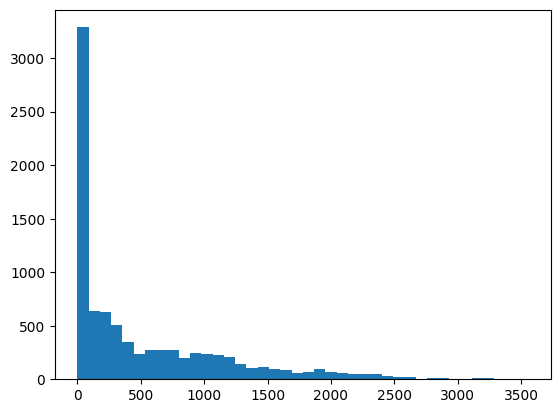

In [104]:
plt.hist(df_datos["Rented Bike Count"], bins=40)
plt.show()

In [105]:
df_datos["Rented Bike Count"].describe()

count    8760.000000
mean      514.740183
std       644.992935
min         0.000000
25%         1.000000
50%       241.000000
75%       842.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

In [138]:
y=df_datos['Rented Bike Count'].groupby(df_datos['Date']).sum()

c:\Users\danie\proyecto_modulo_4_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


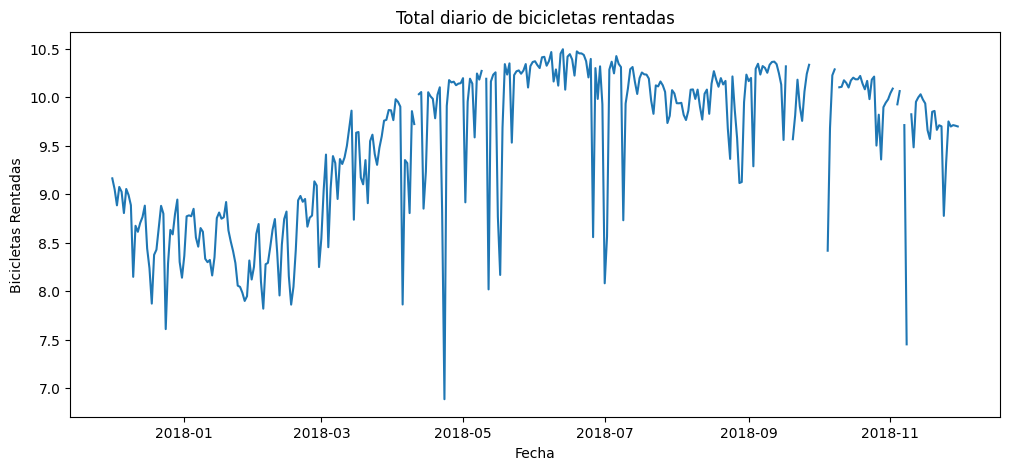

In [139]:
y = np.log(df_datos.groupby('Date')['Rented Bike Count'].sum())
#y = df_datos.groupby('Date')['Rented Bike Count'].sum()
plt.figure(figsize=(12,5))
plt.plot(y.index, y.values)
plt.xlabel('Fecha')
plt.ylabel('Bicicletas Rentadas')
plt.title('Total diario de bicicletas rentadas')
plt.show()

Naturalmente, sabemos que nuestra variable a ajustar es El conteo de la Renta de Bicicletas en 

In [199]:
df_datos_2=pd.get_dummies(
    df_datos,
    columns=["Seasons","Holiday","Functioning Day"],
    drop_first=True,
    dtype=int
)

df_datos_2['Date']=pd.to_datetime(df_datos_2['Date'],format="%d/%m/%Y").dt.date

In [200]:
df_datos_2

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),...,Humidity(%)_scaler,Wind speed (m/s)_scaler,Visibility (10m)_scaler,Dew point temperature(°C)_scaler,Solar Radiation (MJ/m2)_scaler,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,-1.042483,0.458476,0.925871,-1.659605,-0.655132,0,0,1,1,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,-0.993370,-0.892561,0.925871,-1.659605,-0.655132,0,0,1,1,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,-0.944257,-0.699556,0.925871,-1.667262,-0.655132,0,0,1,1,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,-0.895144,-0.796059,0.925871,-1.659605,-0.655132,0,0,1,1,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,-1.091596,0.554978,0.925871,-1.736177,-0.655132,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,...,-1.189822,0.844486,0.751605,-1.100630,-0.655132,0,0,0,1,1
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,...,-1.042483,0.554978,0.925871,-1.070001,-0.655132,0,0,0,1,1
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,...,-0.944257,-1.375075,0.873263,-1.070001,-0.655132,0,0,0,1,1
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,...,-0.846031,-0.699556,0.694064,-1.062344,-0.655132,0,0,0,1,1


In [201]:
df_datos_2.dtypes

Date                                 object
Rented Bike Count                     int64
Hour                                  int64
Temperature(°C)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(°C)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Month                                 int32
Week_day                              int32
Day_Number                            int32
Anio                                  int32
hora_sin                            float64
hora_cos                            float64
Month_sin                           float64
Mont_cos                            float64
es_Weeknd                             int64
es_nevado                             int64
es_lluvioso                           int64
Temperature(°C)_scaler          

In [202]:
#columnas_ols=["hora_sin", "hora_cos", "Month_sin", "Mont_cos", "es_Weeknd", "es_nevado", "es_lluvioso", "Temperature(°C)_scaler", "Humidity(%)_scaler", "Wind speed (m/s)_scaler", "Visibility (10m)_scaler", "Dew point temperature(°C)_scaler", "Solar Radiation (MJ/m2)_scaler", "Seasons_Spring", "Seasons_Summer", "Seasons_Winter", "Holiday_No Holiday", "Functioning Day_Yes"]    
columnas_ols=["hora_sin", "hora_cos", "Month_sin", "Mont_cos", "es_Weeknd", "es_nevado", "es_lluvioso", "Temperature(°C)_scaler", "Humidity(%)_scaler", "Wind speed (m/s)_scaler", "Visibility (10m)_scaler", "Solar Radiation (MJ/m2)_scaler", "Holiday_No Holiday", "Functioning Day_Yes"]    
x_dummies=df_datos_2[columnas_ols]
y=df_datos_2['Rented Bike Count']
fechas=df_datos_2['Date']
          
x_dummies=df_datos_2[columnas_ols]
y=df_datos_2['Rented Bike Count']
fechas=df_datos_2['Date']
          

In [203]:
x_dummies

,hora_sin,hora_cos,Month_sin,Mont_cos,es_Weeknd,es_nevado,es_lluvioso,Temperature(°C)_scaler,Humidity(%)_scaler,Wind speed (m/s)_scaler,Visibility (10m)_scaler,Solar Radiation (MJ/m2)_scaler,Holiday_No Holiday,Functioning Day_Yes
0,0.000000,1.000000,0.000000,1.000000e+00,0,0,0,-1.513957,-1.042483,0.458476,0.925871,-0.655132,1,1
1,0.258819,0.965926,0.500000,8.660254e-01,0,0,0,-1.539074,-0.993370,-0.892561,0.925871,-0.655132,1,1
2,0.500000,0.866025,0.866025,5.000000e-01,0,0,0,-1.580936,-0.944257,-0.699556,0.925871,-0.655132,1,1
3,0.707107,0.707107,1.000000,6.123234e-17,0,0,0,-1.597680,-0.895144,-0.796059,0.925871,-0.655132,1,1
4,0.866025,0.500000,0.866025,-5.000000e-01,0,0,0,-1.580936,-1.091596,0.554978,0.925871,-0.655132,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,-0.965926,0.258819,-0.500000,-8.660254e-01,0,0,0,-0.726961,-1.189822,0.844486,0.751605,-0.655132,1,1
8756,-0.866025,0.500000,-0.866025,-5.000000e-01,0,0,0,-0.793939,-1.042483,0.554978,0.925871,-0.655132,1,1
8757,-0.707107,0.707107,-1.000000,-4.286264e-16,0,0,0,-0.860918,-0.944257,-1.375075,0.873263,-0.655132,1,1
8758,-0.500000,0.866025,-0.866025,5.000000e-01,0,0,0,-0.902779,-0.846031,-0.699556,0.694064,-0.655132,1,1


In [204]:
n = int(len(df_datos_2)*0.8)

X_train = x_dummies.iloc[:n]
X_test = x_dummies.iloc[n:]
fechas_tarin=fechas.iloc[:n]

y_train = y.iloc[:n]
y_test = y.iloc[n:]

In [205]:
print(X_train.dtypes.value_counts())

float64    9
int64      5
Name: count, dtype: int64


In [206]:
print(X_train.dtypes)
#select_dtypes(include=['object'])

hora_sin                          float64
hora_cos                          float64
Month_sin                         float64
Mont_cos                          float64
es_Weeknd                           int64
es_nevado                           int64
es_lluvioso                         int64
Temperature(°C)_scaler            float64
Humidity(%)_scaler                float64
Wind speed (m/s)_scaler           float64
Visibility (10m)_scaler           float64
Solar Radiation (MJ/m2)_scaler    float64
Holiday_No Holiday                  int64
Functioning Day_Yes                 int64
dtype: object


In [ ]:
print(df_datos_2['es_nevado'].value_counts())
print(df_datos_2['es_lluvioso'].value_counts())

Para poder explicar la razón del ajuste con un GLM poisson decidimos ajustar 3 modelos distintos, la forma clasica, que es el OLS, GLM Poisson y GLM Binomial Negativa:

## OLS AJUSTE

In [207]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)

ols = sm.OLS(
    y_train,
    X_train_ols
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     836.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:27:14   Log-Likelihood:                -51909.
No. Observations:                7008   AIC:                         1.038e+05
Df Residuals:                    6993   BIC:                         1.040e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

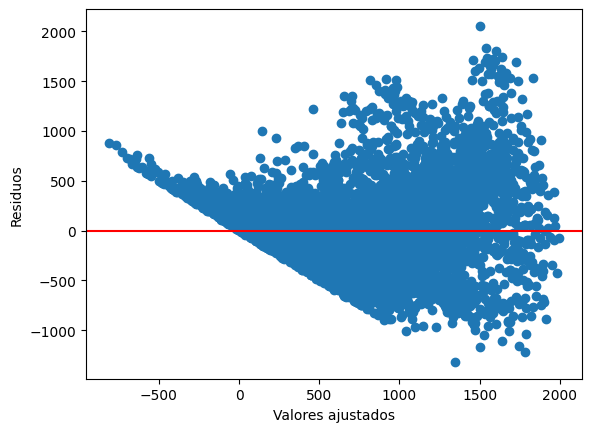

In [209]:
plt.scatter(ols.fittedvalues, ols.resid)
plt.axhline(y=0, color='red')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.show()



Observando los residuos, estos tienen una especie de comportamiento que no es constante lo que viola uno de los supuestos del OLS, heterocedasticidad de los errores.

In [210]:
from scipy.stats import shapiro

stat, p = shapiro(ols.resid)

print('p-value:', p) #es menor a 0.05 por lo que se rechaza la h0, los residuos no sonn normales

p-value: 1.7164260819774867e-36


c:\Users\danie\proyecto_modulo_4_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7008.
  res = hypotest_fun_out(*samples, **kwds)


Usando la prueba de shapiro, verificamos si los residuos son normales, el p-value es menor a 0.05 por lo que se rechaza la hipótesis nula de normalidad, por lo que se viola otro supuesto para poder usar OLS en nuestros datos.

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(ols.resid, ols.model.exog)

print("LM p-value:", bp[1]) #hay autocorrelación

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = pd.DataFrame()
X_vif["Variable"] = X_train_ols.columns
X_vif["VIF"] = [
    variance_inflation_factor(X_train_ols.values, i)
    for i in range(X_train_ols.shape[1])
]

print(X_vif)

In [229]:
#print("Pearson chi2:", ols.pearson_chi2)
print("df_resid:", ols.df_resid)
#print("Deviance:", ols.deviance)

df_resid: 6993.0


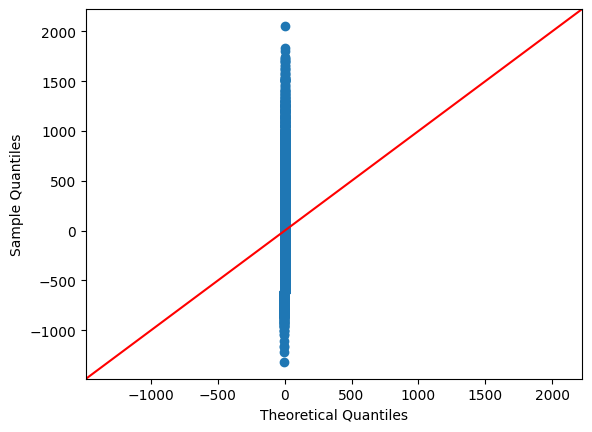

In [211]:
import statsmodels.api as sm
sm.qqplot(ols.resid, line='45')
plt.show()

Esta es una gráfica para poder observar de otra manera de forma visual si los residuos se comportan de forma normal, lo cual claramente no es el caso, además notemos que el modelo da valores menores a 0, lo cuál es incorrecto para la variable que queremos ajustar, una razíon más para evitar usar OLS

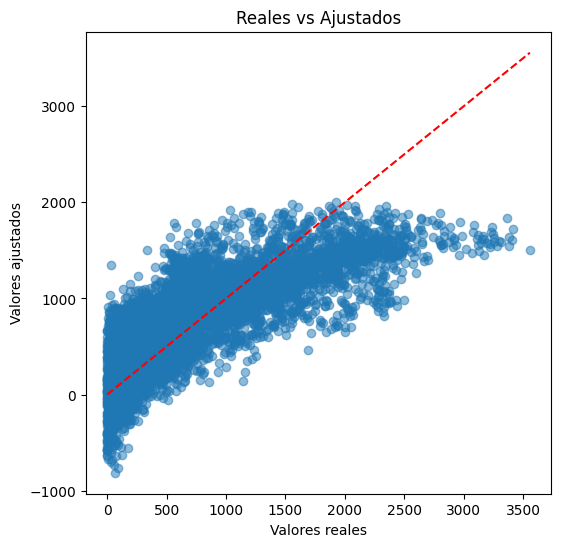

In [ ]:
import matplotlib.pyplot as plt
reales=y_train
ajustados = ols.fittedvalues
plt.figure(figsize=(6,6))

plt.scatter(reales, ajustados, alpha=0.5)

# Línea ideal y=x
plt.plot(
    [reales.min(), reales.max()],
    [reales.min(), reales.max()],
    'r--'
)

plt.xlabel('Valores reales')
plt.ylabel('Valores ajustados')
plt.title('Reales vs Ajustados')
plt.show()

## GLM POISSON AJUSTE

In [ ]:
print(y_train.mean())
print(y_train.var())

Uno de los supuestos del modelo Poisson es que la Varianza es igual a la media, como vemos no se compara, por lo que puede indicar sobre dispersión

In [250]:
modelo_pois = sm.GLM(
    y_train,
    X_train_ols,
    family=sm.families.Poisson()
).fit()

dispersion = modelo_pois.pearson_chi2 / modelo_pois.df_resid
print(dispersion)

170.97959759971644


In [251]:
print("Pearson chi2:", modelo_pois.pearson_chi2)
print("df_resid:", modelo_pois.df_resid)
print("Deviance:", modelo_pois.deviance)

Pearson chi2: 1195660.326014817
df_resid: 6993
Deviance: 1139678.4170421548


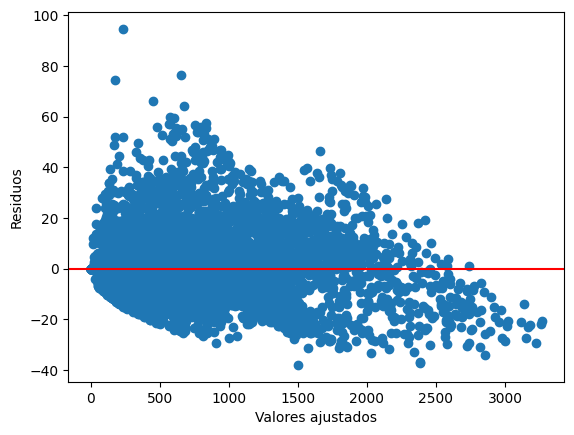

In [252]:
plt.scatter(modelo_pois.fittedvalues, modelo_pois.resid_pearson)
plt.axhline(y=0, color='red')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.show()


Ahora comparrando contra el Modelo OLS podemos observar que este reduce la varianza de los valores ajustados, lo cual mejora mucho mas sin embargo los valores de devianza y el coeficiente de pearson empeoran, lo que puede ser explicado por la sobredispersion ie el supuesto de $E\[Y\]=Var[Y]$ 

## GLM BINOMIAL NEGATIVA AJUSTE

In [232]:
modelo_nb = sm.GLM(
    y_train,
    X_train_ols,
    family=sm.families.NegativeBinomial()
).fit()

dispersion = modelo_nb.pearson_chi2 / modelo_nb.df_resid
print(dispersion)

0.3396220968006192


c:\Users\danie\proyecto_modulo_4_env\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [230]:
print("Pearson chi2:", modelo_nb.pearson_chi2)
print("df_resid:", modelo_nb.df_resid)
print("Deviance:", modelo_nb.deviance)

Pearson chi2: 2374.9773229267303
df_resid: 6993
Deviance: 2427.194699505444


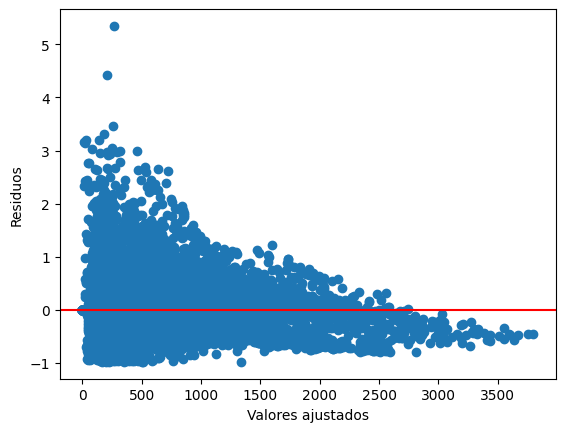

In [239]:
plt.scatter(modelo_nb.fittedvalues, modelo_nb.resid_pearson)
plt.axhline(y=0, color='red')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.show()


In [233]:
print("AIC OLS:", ols.aic)
print("AIC Poisson:", modelo_pois.aic)
print("AIC NegBin:", modelo_nb.aic)

AIC OLS: 103848.45070930739
AIC Poisson: 1194429.5566703985
AIC NegBin: 99787.35027782114


In [253]:
X_test= sm.add_constant(X_test)
pred_ols = ols.predict(X_test)
pred_nb = modelo_nb.predict(X_test)
pred_pois = modelo_pois.predict(X_test)

print("OLS")
print("MAE:", mean_absolute_error(y_test, pred_ols))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ols)))

print("\nNegBin")
print("MAE:", mean_absolute_error(y_test, pred_nb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_nb)))

OLS
MAE: 309.0683842952212
RMSE: 423.509603227928

NegBin
MAE: 307.70434789649835
RMSE: 456.0188403110112


In [254]:
from sklearn.metrics import r2_score

print("R² OLS:", r2_score(y_test, pred_ols))
print("R² Poisson:", r2_score(y_test, pred_pois))
print("R² NegBin:", r2_score(y_test, pred_nb))

R² OLS: 0.5232015914245199
R² Poisson: 0.48159644399509194
R² NegBin: 0.4471926054534531


Con lo anterior podemos dar una justificación de la razón de uso del GLM Poisson y no clásicos como OLS, sin embargo, pudimos llegar a observar una mejoría en el ajuste con GLM Binomial Negativo